# 04 — Jira Effort Estimation: Modeling

Sigue desde [`02_data_preparation.ipynb`](./02_data_preparation.ipynb). El EDA encontró que las 16 escalas de story points no son comparables entre sí, y la preparación de datos dejó planteadas dos alternativas para lidiar con eso. Acá se comparan directamente:

1. Modelo *pooled*: un solo regresor entrenado sobre los 16 proyectos juntos, con `project` como feature categórica, para que aprenda un offset por proyecto.
2. Modelos *por proyecto*: 16 regresores independientes, cada uno entrenado solo con los datos de su propio proyecto — el enfoque que usa el paper académico de origen de este dataset.

El error siempre se reporta en la **escala original de story points** (revirtiendo `log1p` con `expm1`), no en escala log. Un MAE de 2 puntos le dice algo a un Scrum Master; un MAE de 0.3 en log, no.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Carga de datos procesados

In [2]:
train = pd.read_csv('../data/processed_train.csv')
test = pd.read_csv('../data/processed_test.csv')
X_train_emb = np.load('../data/train_embeddings.npy')
X_test_emb = np.load('../data/test_embeddings.npy')

print('Train:', X_train_emb.shape, '| Test:', X_test_emb.shape)

Train: (18642, 384) | Test: (4671, 384)


## 2. Modelo pooled: embeddings + `project` como feature

In [3]:
proj_train = pd.get_dummies(train['project'], prefix='proj')
proj_test = pd.get_dummies(test['project'], prefix='proj').reindex(columns=proj_train.columns, fill_value=0)

X_train_pooled = np.hstack([X_train_emb, proj_train.values])
X_test_pooled = np.hstack([X_test_emb, proj_test.values])
y_train = train['log_storypoint'].values

print('X_train_pooled:', X_train_pooled.shape, '(384 embedding + 16 one-hot de proyecto)')

X_train_pooled: (18642, 400) (384 embedding + 16 one-hot de proyecto)


In [4]:
dummy = DummyRegressor(strategy='median').fit(X_train_pooled, y_train)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_pooled, y_train)
xgb_pooled = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
).fit(X_train_pooled, y_train)

actual = test['storypoint'].values

def evaluate(name, pred_log):
    pred = np.expm1(pred_log)
    mae = mean_absolute_error(actual, pred)
    rmse = mean_squared_error(actual, pred) ** 0.5
    bias = (pred - actual).mean()
    return {'modelo': name, 'MAE': mae, 'RMSE': rmse, 'bias (pred-real)': bias}

pooled_results = pd.DataFrame([
    evaluate('Dummy (mediana)', dummy.predict(X_test_pooled)),
    evaluate('Ridge pooled', ridge.predict(X_test_pooled)),
    evaluate('XGBoost pooled', xgb_pooled.predict(X_test_pooled)),
]).set_index('modelo').round(3)

pooled_results

,MAE,RMSE,bias (pred-real)
modelo,,,
Dummy (mediana),3.256,7.295,-1.062
Ridge pooled,2.967,6.680,-0.381
XGBoost pooled,2.991,6.779,-0.440


Ridge y XGBoost quedan prácticamente empatados. Con solo embeddings más proyecto como features, no parece haber señal adicional que un modelo no lineal pueda aprovechar mejor que uno lineal regularizado. Los dos superan claramente al baseline, eso sí.

Lo que sí me parece un hallazgo relevante para el negocio es el bias negativo: el modelo, igual que los equipos humanos, tiende a subestimar levemente. Está prediciendo por debajo del valor real en promedio — exactamente el mismo problema que motivó el proyecto.

## 3. Modelos por proyecto

Acá van 16 regresores Ridge independientes, cada uno entrenado y evaluado solo con las filas de su propio proyecto. No hace falta incluir la columna de proyecto como feature — ya está implícita en cuál modelo se está usando.

In [5]:
per_project_rows = []
for project in train['project'].unique():
    tr_mask = (train['project'] == project).values
    te_mask = (test['project'] == project).values
    if te_mask.sum() < 5:
        continue

    model = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_emb[tr_mask], train.loc[tr_mask, 'log_storypoint'])
    pred = np.expm1(model.predict(X_test_emb[te_mask]))
    mae = mean_absolute_error(test.loc[te_mask, 'storypoint'], pred)

    per_project_rows.append({
        'project': project, 'n_train': tr_mask.sum(), 'n_test': te_mask.sum(), 'mae_por_proyecto': mae,
    })

per_project_df = pd.DataFrame(per_project_rows).set_index('project')
weighted_mae_per_project = (per_project_df['mae_por_proyecto'] * per_project_df['n_test']).sum() / per_project_df['n_test'].sum()
print(f'MAE ponderado (modelos por proyecto): {weighted_mae_per_project:.3f}')
print(f'MAE del modelo pooled (Ridge): {pooled_results.loc["Ridge pooled", "MAE"]:.3f}')

MAE ponderado (modelos por proyecto): 3.009
MAE del modelo pooled (Ridge): 2.967


## 4. Pooled vs. por proyecto, uno por uno

El MAE ponderado global no cuenta toda la historia. Acá se compara cada proyecto individualmente contra la misma predicción del modelo pooled, restringida a ese proyecto.

In [6]:
test = test.copy()
test['pooled_pred'] = np.expm1(ridge.predict(X_test_pooled))

pooled_by_project = test.groupby('project').apply(
    lambda g: mean_absolute_error(g['storypoint'], g['pooled_pred']), include_groups=False,
).rename('mae_pooled')

comparison = per_project_df.join(pooled_by_project)
comparison['gana'] = np.where(comparison['mae_pooled'] < comparison['mae_por_proyecto'], 'pooled', 'por proyecto')
comparison = comparison.sort_values('mae_pooled')
comparison

,n_train,n_test,mae_por_proyecto,mae_pooled,gana
project,,,,,
duracloud,532,134,0.672906,0.858799,por proyecto
talendesb,694,174,0.927590,0.902156,pooled
bamboo,416,105,0.819340,0.990365,por proyecto
mesos,1344,336,1.091904,1.149896,por proyecto
usergrid,385,97,1.185798,1.510954,por proyecto
appceleratorstudio,2335,584,1.591070,1.526720,pooled
springxd,2820,706,1.555744,1.556987,por proyecto
jirasoftware,281,71,1.551469,1.822452,por proyecto
titanium,1800,451,2.306701,2.284429,pooled


gana
pooled          9
por proyecto    7
Name: count, dtype: int64


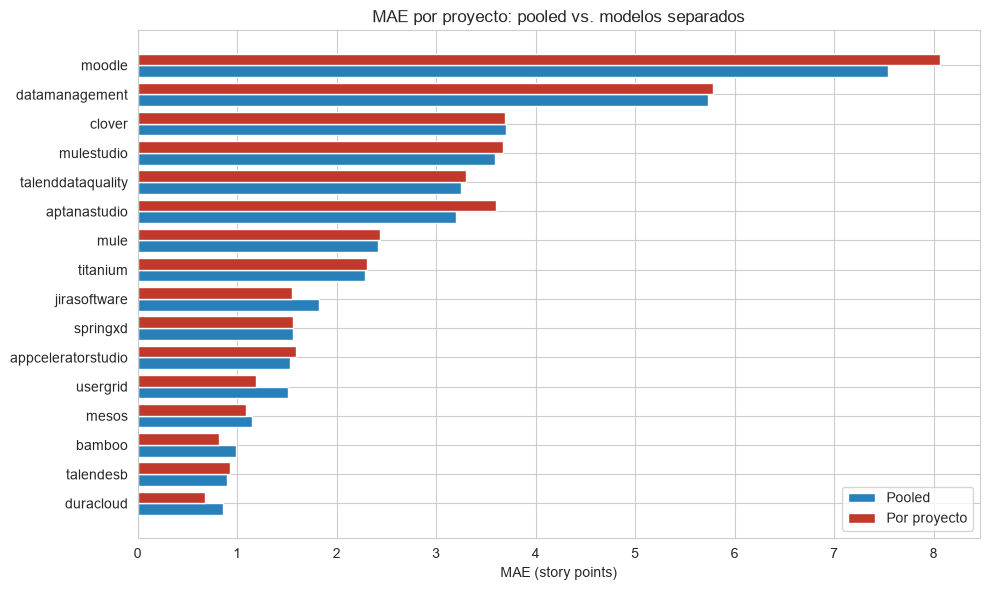

In [7]:
print(comparison['gana'].value_counts())

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(comparison))
ax.barh(y_pos - 0.2, comparison['mae_pooled'], height=0.4, label='Pooled', color='#2980b9')
ax.barh(y_pos + 0.2, comparison['mae_por_proyecto'], height=0.4, label='Por proyecto', color='#c0392b')
ax.set_yticks(y_pos)
ax.set_yticklabels(comparison.index)
ax.set_xlabel('MAE (story points)')
ax.set_title('MAE por proyecto: pooled vs. modelos separados')
ax.legend()
plt.tight_layout()
plt.show()

No hay un ganador claro, y eso en sí mismo ya es una conclusión. Pooled gana en varios de los proyectos más grandes (`datamanagement`, `moodle`, `titanium`), donde compartir señal entre proyectos compensa el ruido de una escala idiosincrática. Los modelos por proyecto, en cambio, ganan en varios de los proyectos con escalas más "limpias" y estándar — `duracloud`, `bamboo`, `mesos`, `usergrid`, `jirasoftware`, los mismos que en el EDA mostraron pocos valores únicos de story points, cercanos a Fibonacci puro.

Esto conecta directamente con el hallazgo de heterogeneidad de escalas del EDA: cuando la escala de un proyecto es estándar y consistente, aislarlo ayuda. Cuando es idiosincrática y con pocos datos, pooling ayuda a compensar.

## 5. Ejemplos de predicciones

In [8]:
sample = test.sample(8, random_state=RANDOM_STATE)[['project', 'issuekey', 'storypoint', 'pooled_pred']].copy()
sample['pooled_pred'] = sample['pooled_pred'].round(1)
sample['error'] = (sample['pooled_pred'] - sample['storypoint']).round(1)
sample

,project,issuekey,storypoint,pooled_pred,error
1714,datamanagement,DM-6905,2,4.2,2.2
3534,springxd,XD-3620,5,2.2,-2.8
3647,springxd,XD-3735,1,2.0,1.0
2509,moodle,MDL-49519,8,9.4,1.4
4063,talendesb,TESB-11750,2,2.2,0.2
4669,usergrid,USERGRID-1272,5,3.4,-1.6
582,appceleratorstudio,TISTUD-8541,3,4.2,1.2
2740,mule,MULE-8741,5,2.4,-2.6


## Lo que queda después de esta fase

1. El modelo pooled (Ridge) tiene un MAE de aproximadamente 3 story points en el set de test. Es mejor que el baseline de predecir siempre la mediana, pero está lejos de ser una estimación precisa. Lo veo como un punto de partida razonable para asistir la estimación humana, no para reemplazarla.
2. Ni pooled ni por-proyecto gana de forma universal. El resultado depende de si la escala del proyecto es estándar (ahí conviene separar) o idiosincrática y con poco volumen (ahí conviene poolear). Esto es consistente con — y en la práctica explica — el hallazgo de heterogeneidad de escalas del EDA.
3. El modelo hereda el sesgo que el proyecto busca corregir: el bias promedio del modelo pooled es negativo, tiende a subestimar, igual que los equipos humanos. Un modelo de asistencia a la estimación no elimina automáticamente el problema de negocio si ese sesgo no se corrige explícitamente — queda pendiente para la fase de evaluación/producto, no se resuelve en este notebook.
4. XGBoost no superó a Ridge sobre este espacio de features (embeddings + proyecto). Con una representación ya densa y de bajo ruido como un embedding de oración, un modelo lineal regularizado termina capturando casi toda la señal disponible.
5. Hay una limitación de alcance que viene heredada de la sustitución de dataset: el dataset sustituto (`issuekey`, `title`, `description`, `storypoint`) no trae timestamps de cambio de estado ni historial de flujo, así que el análisis de cycle time / lead time / cuellos de botella que estaba planteado en el alcance original del proyecto simplemente no es posible con estos datos — a diferencia de lo que sí traía el Public Jira Dataset de Zenodo, descartado por su tamaño (ver `01_eda.ipynb`). Se documenta como limitación en vez de simularla con datos inventados.

El siguiente paso es llevar este análisis a un dashboard en Streamlit, con el enfoque analista que sí es posible con este dataset (distribución de story points por proyecto, características del texto) y el estimador interactivo de story points.